In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
# Import data 
df = pd.read_csv(r'C:\Users\priyanka lokare\Desktop\heart.csv')

In [3]:
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [4]:
# Information of variable 
# Age : age of patient
# Sex : 1: male 0: female 
# cp  : chest pain
# trtbps: Resting blood pressure
# chol: Cholesterol
# Fbs: (Fasting blood sugar)
# Restecg : Resting electrocardiography
# Thalach :Maximum heart rate achieved
# Exang : Exercise induced angima
# Oldpeak :ST depression induced by exercise relative to rest 
# Slope: Slope of the peak exercise ST segment ordinal.
#  Ca : (Calcium)
# Thal (Thalassemia) :

In [5]:
# Now we can examine data using head and tail 

In [6]:
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [7]:
df.tail()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [8]:
# To check null values 
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [9]:
# Conclusion: There is no missing value in our data.

In [10]:
df.shape

(303, 14)

In [11]:
# Conclusion: We can observe that data set contain 303 rows and 14 columns ‘Diagnosis’ is the column
#which weare going to predict, Predicting the patient should be diagnosed with heart disease
#Positive(1) or negative(o) 

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [13]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [14]:
# We can seprate positive and negative diagnosis function using below method

In [15]:
df['output'].value_counts()

1    165
0    138
Name: output, dtype: int64

In [16]:
# There are 165 patients having heart disease.

In [17]:
# Bar diagram #

In [18]:
from matplotlib import rcParams

Text(0.5, 1.0, 'Count of each output')

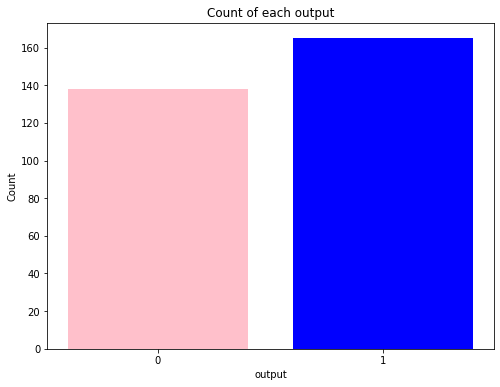

In [19]:
rcParams['figure.figsize'] = 8,6
plt.bar(df['output'].unique(), df['output'].value_counts(), color = ['blue', 'pink'])
plt.xticks([0, 1])
plt.xlabel('output')
plt.ylabel('Count')
plt.title('Count of each output')

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x00000182C7BE3310>,
      dtype=object)

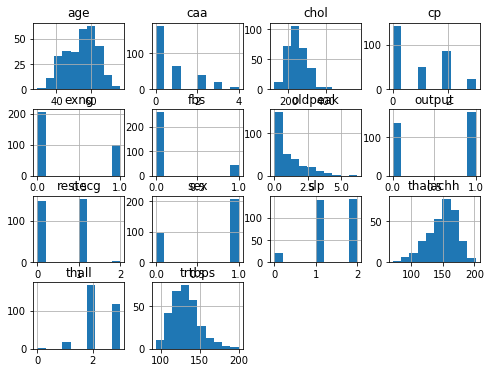

In [20]:
df.hist()

In [21]:
# Pairplot #
# Pairplots are also great way to immediately see the correlationship between all variables.

In [22]:
import seaborn as sns

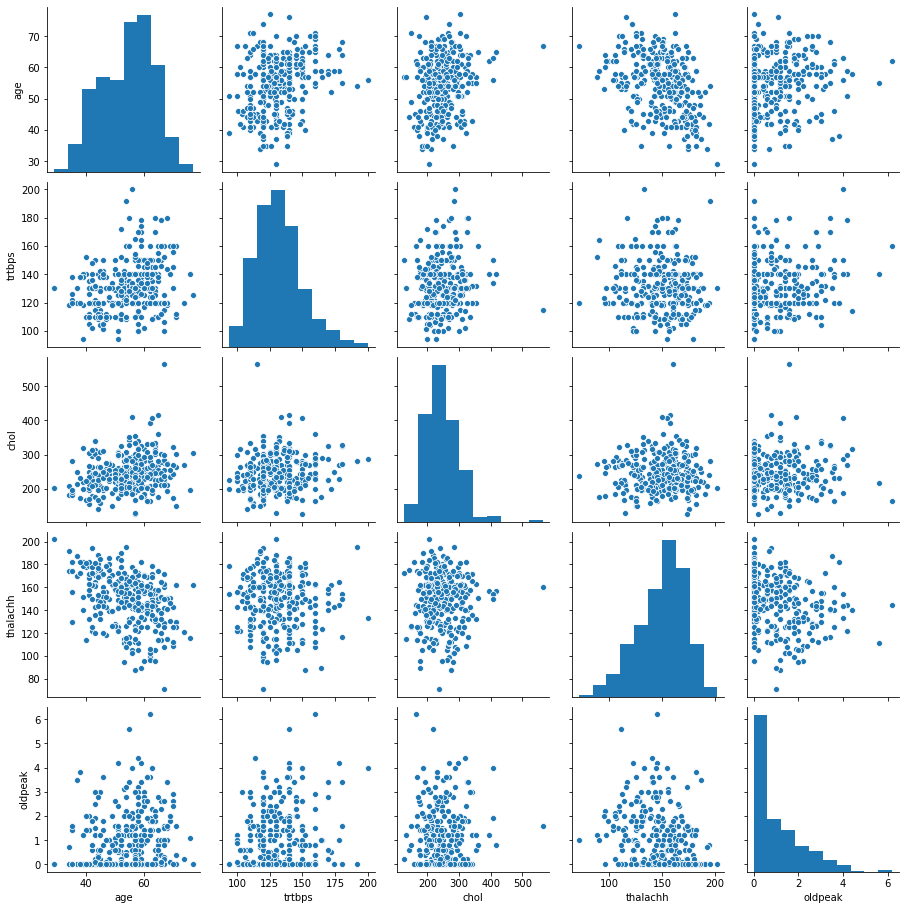

In [23]:
df1 = df[['age','trtbps','chol','thalachh','oldpeak']]
sns.pairplot(df1)

In [24]:
#The histogram of age shows that the negatively skewed distribution. 
#2)The histogram of trestbps shows that the positively skewed distribution.
#3)The histogram of chol shows that the positively skewed distribution. 
#4)The histogram of thalachh shows that the negatively skewed distribution. 
#The histogram of oldpeak shows that the positively skewed distribution

In [25]:
# Correlation Matrix # 

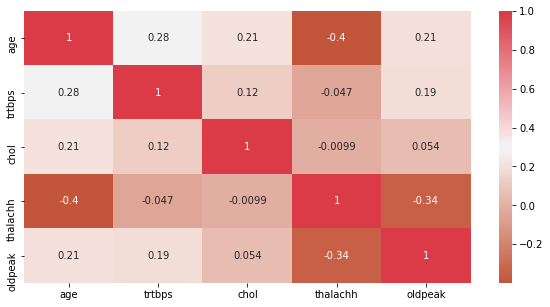

In [26]:
subData = df[['age','trtbps','chol','thalachh','oldpeak']]
corr = subData.corr()
plt.subplots(figsize=(10,5))
 
sns.heatmap(corr, xticklabels=corr.columns,
            yticklabels=corr.columns,
           annot=True,
           cmap=sns.diverging_palette(20, 10, as_cmap=True))

In [27]:
# Filtering data by positive & negative heart disease patients 

In [28]:
# 1]Filtering data by positive  heart disesase patient #

In [29]:
nnn_data = df[df['output']==1]

In [30]:
nnn_data.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.0
mean,52.496970,0.563636,1.375758,129.303030,242.230303,0.139394,0.593939,158.466667,0.139394,0.583030,1.593939,0.363636,2.121212,1.0
std,9.550651,0.497444,0.952222,16.169613,53.552872,0.347412,0.504818,19.174276,0.347412,0.780683,0.593635,0.848894,0.465752,0.0
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,96.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,44.000000,0.000000,1.000000,120.000000,208.000000,0.000000,0.000000,149.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.0
50%,52.000000,1.000000,2.000000,130.000000,234.000000,0.000000,1.000000,161.000000,0.000000,0.200000,2.000000,0.000000,2.000000,1.0
75%,59.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,172.000000,0.000000,1.000000,2.000000,0.000000,2.000000,1.0
max,76.000000,1.000000,3.000000,180.000000,564.000000,1.000000,2.000000,202.000000,1.000000,4.200000,2.000000,4.000000,3.000000,1.0


In [31]:
print("(Positive Patients thalach): " + str(nnn_data['thalachh'].mean()))

(Positive Patients thalach): 158.46666666666667


In [32]:
# Conclusion: Mean of positive thalachh patient is 158.4666

In [33]:
nnn_data = df[df['output']==0]

In [34]:
nnn_data.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.0
mean,56.601449,0.826087,0.478261,134.398551,251.086957,0.159420,0.449275,139.101449,0.550725,1.585507,1.166667,1.166667,2.543478,0.0
std,7.962082,0.380416,0.905920,18.729944,49.454614,0.367401,0.541321,22.598782,0.499232,1.300340,0.561324,1.043460,0.684762,0.0
min,35.000000,0.000000,0.000000,100.000000,131.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,52.000000,1.000000,0.000000,120.000000,217.250000,0.000000,0.000000,125.000000,0.000000,0.600000,1.000000,0.000000,2.000000,0.0
50%,58.000000,1.000000,0.000000,130.000000,249.000000,0.000000,0.000000,142.000000,1.000000,1.400000,1.000000,1.000000,3.000000,0.0
75%,62.000000,1.000000,0.000000,144.750000,283.000000,0.000000,1.000000,156.000000,1.000000,2.500000,1.750000,2.000000,3.000000,0.0
max,77.000000,1.000000,3.000000,200.000000,409.000000,1.000000,2.000000,195.000000,1.000000,6.200000,2.000000,4.000000,3.000000,0.0


In [35]:
# 2]Filtering data by negative  heart disesase patient #

In [36]:
print("(Negative Patients thalach): " + str(nnn_data['thalachh'].mean()))

(Negative Patients thalach): 139.1014492753623


In [37]:
# Conclusion: Mean of negative thalachh patient is 139.1014

In [38]:
# Conclusion: Overall conclusion is From comparing positive and negative patients we can see there are vast differences in means
#for many of our 13 Features. From examining the details, we can observe that positive patients increase maximum heart rate 
#achieved

In [39]:
# Logistic Regression #
# Logistic regression is a supervised learning classification algorithm used to predict the probability
# of a target variable.Our output is dichotomous in short dependent variable is binary.

In [40]:
import scipy.optimize as opt
import statsmodels.api as sm
from sklearn import preprocessing
'exec(% matplotlib inline)'
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import seaborn as sn

In [41]:
from sklearn.metrics import classification_report

In [42]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [43]:
print("shape of X= ",x.shape)

shape of X=  (303, 13)


In [44]:
print("shape of y= ",y.shape)

shape of y=  (303,)


In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( 
        x, y, test_size = 0.2, random_state = 1)

In [48]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( 
        x, y, test_size = 0.3, random_state = 1)
print ('Train set:', x_train.shape,  y_train.shape)
print ('Test set:', x_test.shape,  y_test.shape)

Train set: (212, 13) (212,)
Test set: (91, 13) (91,)


In [49]:
from sklearn.linear_model import LogisticRegression
model1=LogisticRegression(random_state=1)
model1.fit(x_train,y_train)

C:\Users\priyanka lokare\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=1)

In [50]:
y_pred1 = model1.predict(x_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.81      0.73      0.77        41
           1       0.80      0.86      0.83        50

    accuracy                           0.80        91
   macro avg       0.80      0.80      0.80        91
weighted avg       0.80      0.80      0.80        91



In [51]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
  

In [52]:
cm = confusion_matrix(y_test, y_pred1)
print(cm)
accuracy_score(y_test, y_pred1)


[[30 11]
 [ 7 43]]


0.8021978021978022

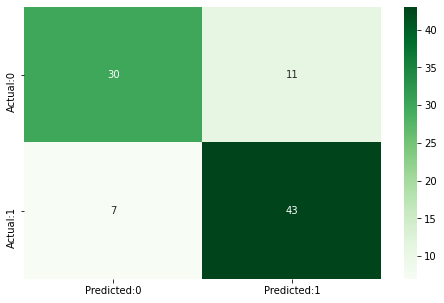

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.81      0.73      0.77        41
           1       0.80      0.86      0.83        50

    accuracy                           0.80        91
   macro avg       0.80      0.80      0.80        91
weighted avg       0.80      0.80      0.80        91



In [53]:
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (8, 5))
sn.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")
plt.show()
  
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred1))
  

In [54]:
# Conclusion: From the above confusion matrix we calculate the accuracy 
# Accuracy = Number of correct prediction/ Total number of prediction
#           = 30 + 43/ 30 + 43 + 11 + 7 
#           = 73/ 91 
#           = 0.8021
# Logistic regression accuracy is 0.80

In [55]:
# 2] RANDOM FOREST #

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [57]:
model2 = RandomForestClassifier(random_state=1)
model2.fit(x_train, y_train)

RandomForestClassifier(random_state=1)

In [58]:
y_pred2 = model2.predict(x_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        41
           1       0.76      0.74      0.75        50

    accuracy                           0.73        91
   macro avg       0.72      0.72      0.72        91
weighted avg       0.73      0.73      0.73        91



In [59]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
  

In [60]:
cm = confusion_matrix(y_test, y_pred2)
print(cm)
accuracy_score(y_test, y_pred2)


[[29 12]
 [13 37]]


0.7252747252747253

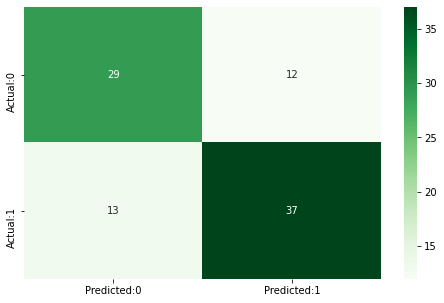

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        41
           1       0.76      0.74      0.75        50

    accuracy                           0.73        91
   macro avg       0.72      0.72      0.72        91
weighted avg       0.73      0.73      0.73        91



In [61]:
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (8, 5))
sn.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")
plt.show()
  
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred2))
  

In [62]:
# Conclusion : Random forest accuracy is 0.72

In [ ]:
# 3] Naive Bayes 

In [64]:
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB

In [65]:
model3 = GaussianNB()
model3.fit(x_train,y_train)

GaussianNB()

In [66]:
y_pred3 = model3.predict(x_test)
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77        41
           1       0.82      0.80      0.81        50

    accuracy                           0.79        91
   macro avg       0.79      0.79      0.79        91
weighted avg       0.79      0.79      0.79        91



In [67]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
  

In [68]:
cm = confusion_matrix(y_test, y_pred3)
print(cm)
accuracy_score(y_test, y_pred3)


[[32  9]
 [10 40]]


0.7912087912087912

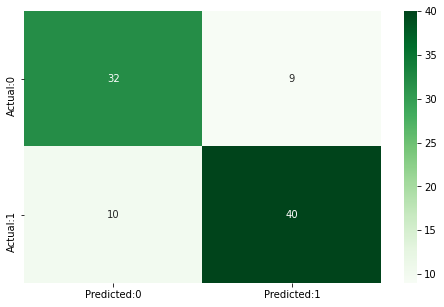

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.76      0.78      0.77        41
           1       0.82      0.80      0.81        50

    accuracy                           0.79        91
   macro avg       0.79      0.79      0.79        91
weighted avg       0.79      0.79      0.79        91



In [69]:
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (8, 5))
sn.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")
plt.show()
  
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred3))
  

In [70]:
# Conclusion: Naive bayes accuracy is 0.79

In [71]:
# 4] SVM

In [72]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC

In [73]:
model4 = SVC(random_state=1)
model4.fit(x_train,y_train)

SVC(random_state=1)

In [74]:
y_pred4 = model4.predict(x_test)
print(classification_report(y_test, y_pred4))

              precision    recall  f1-score   support

           0       0.59      0.46      0.52        41
           1       0.63      0.74      0.68        50

    accuracy                           0.62        91
   macro avg       0.61      0.60      0.60        91
weighted avg       0.61      0.62      0.61        91



In [75]:
cm = confusion_matrix(y_test, y_pred3)
print(cm)
accuracy_score(y_test, y_pred4)

[[32  9]
 [10 40]]


0.6153846153846154

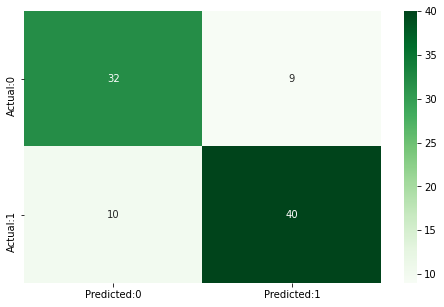

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.59      0.46      0.52        41
           1       0.63      0.74      0.68        50

    accuracy                           0.62        91
   macro avg       0.61      0.60      0.60        91
weighted avg       0.61      0.62      0.61        91



In [76]:
conf_matrix = pd.DataFrame(data = cm, 
                           columns = ['Predicted:0', 'Predicted:1'], 
                           index =['Actual:0', 'Actual:1'])
plt.figure(figsize = (8, 5))
sn.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "Greens")
plt.show()
  
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred4))
  

In [77]:
# Conclusion: SVM accuracy is 0.61

In [78]:
# Overall conclusion by comparing above 4 models Logistic regression having highest accuracy

In [79]:
# THE FEATURE IMPORTENCE # 

In [80]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')

In [81]:
#1] Feature importance based on mean decrease in impurity
# Feature importances are provided by the fitted attribute feature_importances_ and they are computed as the mean and 
#standard deviation of accumulation of the impurity decrease within each tree.

In [82]:
feature_names = ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall']

In [83]:
import time
import numpy as np

start_time = time.time()
importances = model2.feature_importances_
std = np.std([
    tree.feature_importances_ for tree in model2.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: "
      f"{elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.096 seconds


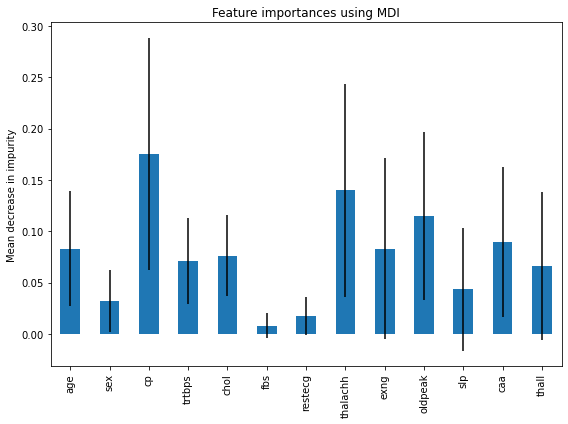

In [84]:
import pandas as pd
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()


In [85]:
# Conclusion: From the above Features importance graph we can conclude that top 4 significant features are
# Cp (chest pain), Thalach (Maximum heart rate achieved),Ca (number of major vessels), Oldpeak.


In [86]:
# 2] Feature importance based on feature permutation
# Permutation feature importance overcomes limitations of the impurity-based feature importance: 
# they do not have a bias toward high-cardinality features and can be computed on a left-out test set.

In [87]:
from sklearn.inspection import permutation_importance

start_time = time.time()
result = permutation_importance(
    model2, x_test, y_test, random_state=1)
elapsed_time = time.time() - start_time
print(f"Elapsed time to compute the importances: "
      f"{elapsed_time:.3f} seconds")

forest_importances = pd.Series(result.importances_mean, index=feature_names)

Elapsed time to compute the importances: 1.834 seconds


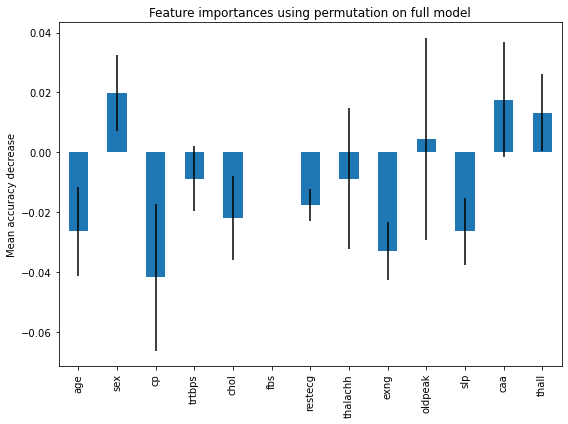

In [88]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()
